# **Understanding Airbnb Market Demand and Listing Segments in California**
---
**Subject:** ISBA 2403 - Machine Learning with Python  
**Quarter:** Winter 2026  
**Professor:** Dr. Amber Xiaoyan Liu  
**Team Number:** 15  

**Team Members:**
* Tanish Jagadheshan
* Nikita Xu
* Krishi Konindala
* Kayal Rajkumar
* Doris Wang
* Aditya Prasad
---

### **Table of Contents**

**[1. Importing Libraries](#sec-1)**

**[2. Dataset Loading](#sec-2)**

**[3. Dataset Overview](#sec-3)**

**[4. Data Pre-Processing](#sec-4)**
- [4.1 Data Cleaning](#sec-4-1)
- [4.2 Handling Missing Values, Prices and Outliers](#sec-4-2)
- [4.3 Final Preprocessing Checks](#sec-4-3)

**[5. Exploratory Data Analysis](#sec-5)**
- [5.1 Number of Listings](#sec-5-1)
- [5.2 Types of Accommodation](#sec-5-2)
- [5.3 Price Distribution Per Night](#sec-5-3)
- [5.4 Price Distribution by Room Type](#sec-5-4)

**[6. Predictive Modeling](#sec-6)**
- [6.1 Demand Driver Analysis](#sec-6-1)
    - [6.1.1 Preprocessing for Demand Driver Analysis](#sec-6-1-1)
    - [6.1.2 Feature Selection for Demand Driver Analysis](#sec-6-1-2)
    - [6.1.3 Baseline Model Comparison](#sec-6-1-3)
    - [6.1.4 Cross Validation and Hyperparameter Tuning](#sec-6-1-4)
    - [6.1.5 Deep Dive: Market-Specific Demand Driver Analysis](#sec-6-1-5)
    - [6.1.6 Heatmap: Key Drivers Across California](#sec-6-1-6)
    - [6.1.7 Top 5 Demand Drivers in Santa Clara County](#sec-6-1-7)
    - [6.1.8 Los Angeles vs Pacific Grove Comparison](#sec-6-1-8)
    - [6.1.9 Actionable Recommendations](#sec-6-1-9)
- [6.2 Clustering Analysis](#sec-6-2)
    - [6.2.1 Feature Selection](#sec-6-2-1)
    - [6.2.2 Handling Missing Values (Imputing with Median)](#sec-6-2-2)
    - [6.2.3 Scaling using Standard Scaler](#sec-6-2-3)
    - [6.2.4 Finding Optimal Clusters: Elbow Method](#sec-6-2-4)
    - [6.2.5 Finding Optimal Clusters: Silhouette Score](#sec-6-2-5)
    - [6.2.6 K-Means Clustering](#sec-6-2-6)
    - [6.2.7 Price Distribution of Clusters](#sec-6-2-7)
    - [6.2.8 K-Means PCA Cluster Map](#sec-6-2-8)
    - [6.2.9 DBSCAN Analysis](#sec-6-2-9)
    - [6.2.10 Actionable Recommendations: Clustering Analysis](#sec-6-2-10)

**[7. Predictive Question](#sec-7)**

**[8. Conclusion](#sec-8)**


<a id="sec-1"></a>
### **1. Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.impute import KNNImputer

<a id="sec-2"></a>
---
### **2. Dataset Loading**

In [2]:
la = pd.read_csv("LosAngeles.csv")
oak = pd.read_csv("Oakland.csv")
pg = pd.read_csv("PacificGrove.csv")
sd = pd.read_csv("SanDiego.csv")
sf = pd.read_csv("SanFrancisco.csv")
sm = pd.read_csv("SanMateoCounty.csv")
sclara = pd.read_csv("SantaClaraCounty.csv")
scruz = pd.read_csv("SantaCruzCounty.csv")

print("Data Loaded")

Data Loaded


<a id="sec-3"></a>
---
### **3. Dataset Overview**

In [3]:
datasets = {
    "LA": la,
    "Oakland": oak,
    "PacificGrove": pg,
    "SanDiego": sd,
    "SF": sf,
    "SanMateo": sm,
    "SantaClara": sclara,
    "SantaCruz": scruz
}

for name, df in datasets.items():
    print(name, ":", df.shape[0], "rows")

#df.describe()
#df.shape
#df.isnull().sum()

LA : 45886 rows
Oakland : 2250 rows
PacificGrove : 293 rows
SanDiego : 13162 rows
SF : 7780 rows
SanMateo : 3516 rows
SantaClara : 6940 rows
SantaCruz : 1760 rows


<a id="sec-4"></a>
---
### **4. Data Pre-Processing**

<a id="sec-4-1"></a>
#### 4.1 Data Cleaning

In [4]:
# Create Dictionary
location_dfs = {
    "LosAngeles": la,
    "Oakland": oak,
    "PacificGrove": pg,
    "SanDiego": sd,
    "SanFrancisco": sf,
    "SanMateoCounty": sm,
    "SantaClaraCounty": sclara,
    "SantaCruzCounty": scruz
}

# Keep Selected Columns
columns_to_keep = [
    # Location
    "location", "latitude", "longitude",
    
    # Host Information
    "host_is_superhost", "host_identity_verified", "host_has_profile_pic",
    "hosts.time_as_host_years", "host_response_time", "host_acceptance_rate", 
    "host_listings_count", "calculated_host_listings_count",
    
    # Property Details
    "property_type", "room_type", "accommodates", 
    "bathrooms", "bedrooms", "beds", "price", 
    
    # Availability
    "availability_30", "availability_60", "availability_90", "availability_365", 
    
    # Reviews & Scores
    "first_review", "last_review", "number_of_reviews", 
    "number_of_reviews_ltm", "reviews_per_month", 
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness", 
    "review_scores_checkin", "review_scores_communication", "review_scores_location", 
    "review_scores_value"
]

# Add location and filter columns for each dataframe
cleaned_dfs = []
for location_name, df in location_dfs.items():
    # Append the location column
    temp_df = df.assign(location=location_name)
    # Keep only target columns
    valid_cols = [col for col in columns_to_keep if col in temp_df.columns]
    # Append the filtered dataframe to our list
    cleaned_dfs.append(temp_df[valid_cols])

# Combined Dataframe
combined_df = pd.concat(cleaned_dfs, ignore_index=True)

# Final Checks
print(f"Combined Shape: {combined_df.shape[0]} rows, {combined_df.shape[1]} columns\n")
combined_df.head(5)

Combined Shape: 81587 rows, 33 columns



,location,latitude,longitude,host_is_superhost,host_identity_verified,host_has_profile_pic,host_response_time,host_acceptance_rate,host_listings_count,calculated_host_listings_count,...,number_of_reviews,number_of_reviews_ltm,reviews_per_month,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,LosAngeles,34.09625,-118.34605,t,t,t,within an hour,100%,2.0,2,...,45,2,0.33,4.87,4.82,4.93,5.00,4.98,4.96,4.87
1,LosAngeles,34.00440,-118.48095,f,t,t,within an hour,40%,2.0,2,...,24,0,0.14,4.41,4.26,4.58,4.39,4.48,4.91,4.22
2,LosAngeles,33.87490,-118.11515,f,t,t,NaN,NaN,1.0,1,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LosAngeles,34.16887,-118.64478,f,t,t,within an hour,85%,13.0,6,...,19,0,0.10,4.38,4.18,4.00,4.59,4.35,4.65,4.29
4,LosAngeles,34.09626,-118.34372,t,t,t,within an hour,100%,2.0,2,...,37,3,0.19,4.86,4.85,4.91,4.91,4.91,4.71,4.76


<a id="sec-4-2"></a>
#### 4.2 Handling Missing Values, Prices and Outliers

In [5]:
# Convert "has_reviews" to boolean (TRUE if listing has at least 1 review, FALSE if 0 reviews)
combined_df["has_reviews"] = combined_df["number_of_reviews"] > 0

review_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value"
]

# Impute missing review scores with 0
combined_df[review_cols] = combined_df[review_cols].fillna(0)

# Clean price column
combined_df["price"] = (
    combined_df["price"]
    .astype(str)
    .str.replace(r"[$,]", "", regex=True)
)
combined_df["price"] = pd.to_numeric(combined_df["price"], errors="coerce")

# Remove price outliers (Top 1%)
upper = combined_df["price"].quantile(0.99)
combined_df = combined_df[(combined_df["price"].isna()) | (combined_df["price"] <= upper)]

<a id="sec-4-3"></a>
#### 4.3 Final Preprocessing Checks

In [6]:
# Check value counts before and after cleaning
combined_raw = pd.concat(cleaned_dfs, ignore_index=True)
before_counts = combined_raw["location"].value_counts()
after_counts = combined_df["location"].value_counts()

comparison = pd.concat([before_counts, after_counts], axis=1)
comparison.columns = ["Before Cleaning", "After Cleaning"]
comparison["Rows Removed"] = comparison["Before Cleaning"] - comparison["After Cleaning"]

print(comparison)

                  Before Cleaning  After Cleaning  Rows Removed
location                                                       
LosAngeles                  45886           45512           374
SanDiego                    13162           13027           135
SanFrancisco                 7780            7748            32
SantaClaraCounty             6940            6879            61
SanMateoCounty               3516            3484            32
Oakland                      2250            2245             5
SantaCruzCounty              1760            1735            25
PacificGrove                  293             293             0


<a id="sec-5"></a>
---

### **5. Exploratory Data Analysis**

<a id="sec-5-1"></a>
#### 5.1 Number of Listings

/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_33757/3004153963.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


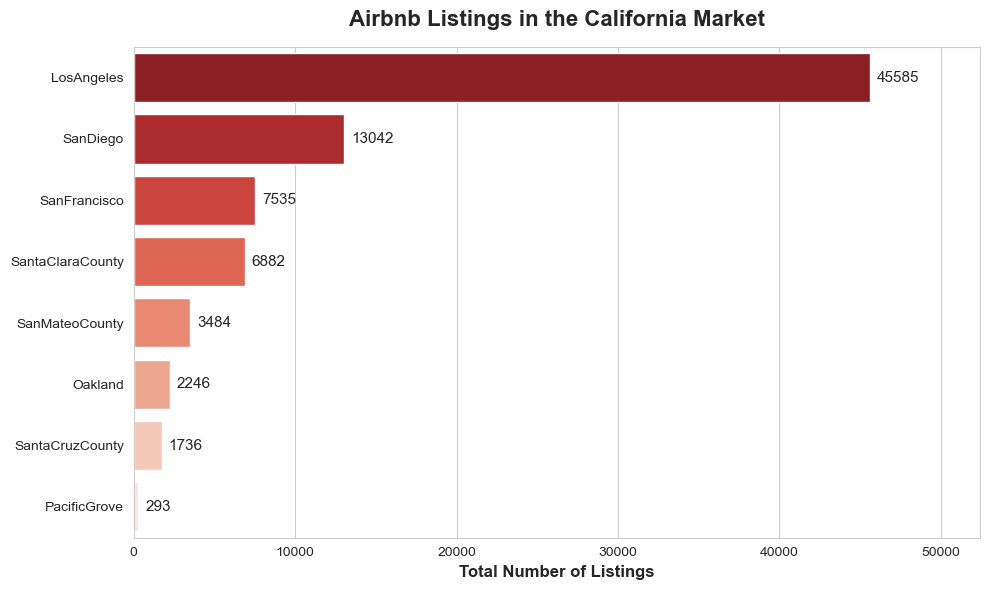

In [37]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=combined_df, 
    y='location', 
    order=combined_df['location'].value_counts().index, 
    palette='Reds_r'
)
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11)

plt.title('Airbnb Listings in the California Market', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Number of Listings', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.xlim(0, combined_df['location'].value_counts().max() * 1.15) # Add space for labels
plt.tight_layout()
plt.show()

<a id="sec-5-2"></a>
#### 5.2 Types of Accomodation

/var/folders/l6/vdcsyn8d1_jf1jgk0_sm23fc0000gn/T/ipykernel_33757/2367767778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=combined_df, x='room_type', order=room_order, palette='Reds_r')


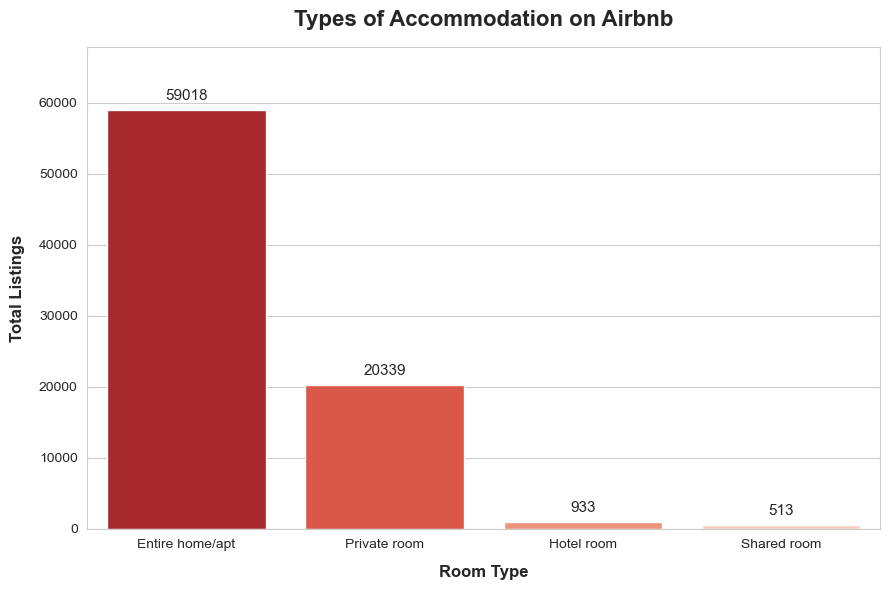

In [38]:
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
room_order = combined_df['room_type'].value_counts().index

ax = sns.countplot(data=combined_df, x='room_type', order=room_order, palette='Reds_r')
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11)

plt.title('Types of Accommodation on Airbnb', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Room Type', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Listings', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, combined_df['room_type'].value_counts().max() * 1.15)
plt.tight_layout()
plt.show()

<a id="sec-5-3"></a>
#### 5.3 Price Distribution Per Night

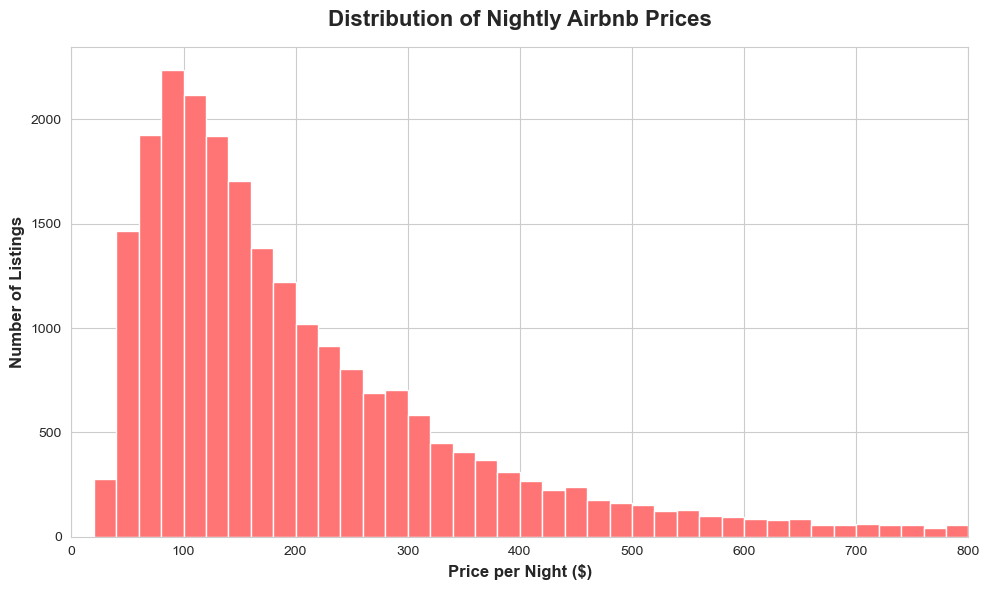

In [39]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=combined_df, 
    x='price', 
    binwidth=20,            
    binrange=(0, 800),      
    color='#FF7474',        
    edgecolor='white',      
    alpha=1.0               
)

plt.title('Distribution of Nightly Airbnb Prices', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price per Night ($)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Listings', fontsize=12, fontweight='bold')
plt.xlim(0, 800)
plt.tight_layout()
plt.show()

<a id="sec-5-4"></a>
#### 5.4 Price Distribution by Room Type

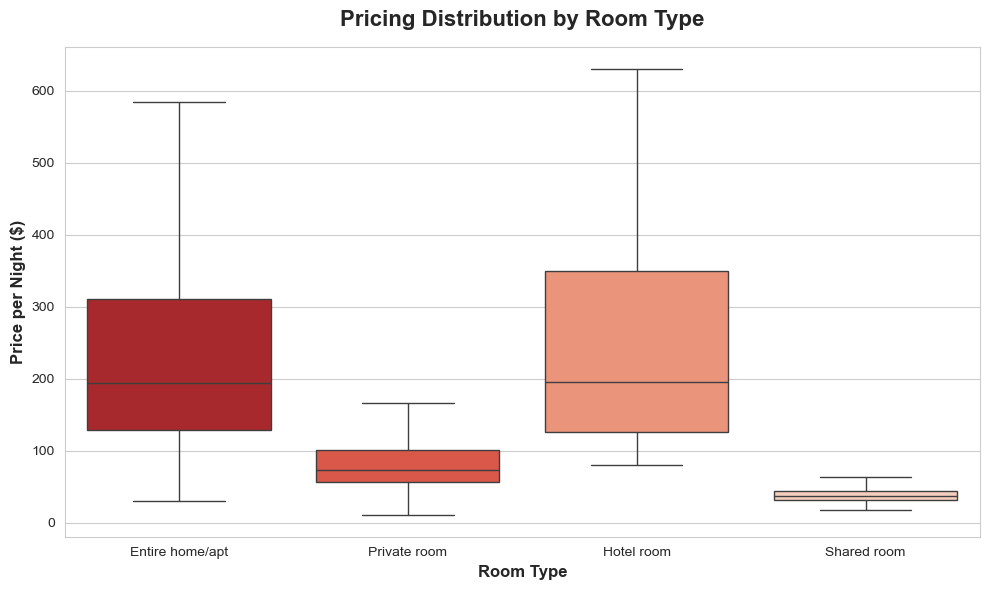

In [40]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
room_order = combined_df['room_type'].value_counts().index

ax = sns.boxplot(
    data=combined_df, 
    x='room_type', 
    y='price', 
    order=room_order,
    hue='room_type',         
    hue_order=room_order,    
    palette='Reds_r',
    showfliers=False,  
    legend=False
)

plt.title('Pricing Distribution by Room Type', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Room Type', fontsize=12, fontweight='bold')
plt.ylabel('Price per Night ($)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

<a id="sec-6"></a>
### **6. Predictive Modeling**

<a id="sec-6-1"></a>
---

#### **6.1. Demand Driver Analysis** : How do the key drivers of Airbnb listing demand vary across different locations in California?

Models Used: `Linear Regression` | `Random Forest` | `XGBoost`


<a id="sec-6-1-1"></a>
#### 6.1.1 Feature Selection for Demand Driver Analysis


*The **Target Variable is Reviews Per Month** : In the domain of short-term rental analytics, Reviews per Month is considered the industry standard for demand as Airbnb does not publicly disclose exact booking counts or precise revenue per listing. Review volume is a reliable signal for how active and sought-after a listing is across different regions.*

In [45]:
mydata = combined_df.copy()

# Target variable
TARGET = "reviews_per_month"

# Feature Selection
candidate_features = [
    "latitude", "longitude", "hosts.time_as_host_years", "host_response_time",
    "host_acceptance_rate", "host_listings_count", "host_identity_verified",
    "host_has_profile_pic", "property_type", "accommodates", "bathrooms",
    "bedrooms", "beds", "room_type", "price", "availability_30",
    "availability_60", "availability_90", "availability_365",
    "number_of_reviews", "calculated_host_listings_count",
    "number_of_reviews_ltm", "host_is_superhost",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value", "has_reviews"
]

# Keep only columns that exist in the dataset
feature_cols = [c for c in candidate_features if c in mydata.columns]

# Check if all markets are included
markets = sorted(mydata["location"].dropna().unique())
print("Markets included:")
print(markets)
print("Total markets:", len(markets))

Markets included:
['LosAngeles', 'Oakland', 'PacificGrove', 'SanDiego', 'SanFrancisco', 'SanMateoCounty', 'SantaClaraCounty', 'SantaCruzCounty']
Total markets: 8


<a id="sec-6-1-2"></a>
#### 6.1.2 Pre-Processing for Demand Driver Analysis

*The **Target Variable is Reviews Per Month** : In the domain of short-term rental analytics, Reviews per Month is considered the industry standard for demand as Airbnb does not publicly disclose exact booking counts or precise revenue per listing. Review volume is a reliable signal for how active and sought-after a listing is across different regions.*


In [46]:
# Handle missing values in the target variable
mydata[TARGET] = mydata[TARGET].fillna(0)

# Clean percentages
if "host_acceptance_rate" in mydata.columns:
    mydata["host_acceptance_rate"] = (
        mydata["host_acceptance_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
    )
    mydata["host_acceptance_rate"] = pd.to_numeric(mydata["host_acceptance_rate"], errors="coerce")

#Clean boolean strings
bool_cols = ["host_identity_verified", "host_has_profile_pic", "host_is_superhost"]
for col in bool_cols:
    if col in mydata.columns:
        mydata[col] = mydata[col].replace({"t": 1, "f": 0})

# Fill remaining missing NA values in numerical columns
num_cols = mydata[feature_cols].select_dtypes(include=['float64', 'int64', 'bool']).columns
for col in num_cols:
    mydata[col] = mydata[col].fillna(mydata[col].median())

# One Hot Encode Categorical Columns
cat_cols = ["host_response_time", "property_type", "room_type"]
cat_cols_present = [c for c in cat_cols if c in mydata.columns]

# Extract only the target, location and features we require
final_columns_to_keep = feature_cols + [TARGET, "location"]
ml_df = mydata[final_columns_to_keep].copy()

# Apply One-Hot Encoding
ml_df = pd.get_dummies(ml_df, columns=cat_cols_present, drop_first=True)

# Final Check
print(f"Final Data Shape: {ml_df.shape}")
print(f"Remaining Missing Values: {ml_df.drop(columns=['location']).isnull().sum().sum()}")

Final Data Shape: (80923, 138)
Remaining Missing Values: 0


/var/folders/m3/33bct_y126z5372tg61hsy3c0000gn/T/ipykernel_1165/3778066749.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mydata[col] = mydata[col].replace({"t": 1, "f": 0})


<a id="sec-6-1-3"></a>
#### 6.1.3 Baseline Model Comparison Test

*To understand the key drivers of Airbnb demand, we first compare three models using our features. We use an **80/20 Train-Test Split** to evaluate initial performance across **Linear Regression**, **Random Forest** and **XGBoost**.*

In [47]:
cols_to_drop = ['location', TARGET, 'number_of_reviews', 'number_of_reviews_ltm']
cols_to_drop = [c for c in cols_to_drop if c in ml_df.columns]

#Feature (X)
X = ml_df.drop(columns=cols_to_drop)
#Target (y)
y = ml_df[TARGET]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use Models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1)
}

# Training and Evaluation
evaluation_results = {}
for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)
    
    # Predict
    predictions = model.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    evaluation_results[name] = {'R-squared': r2, 'RMSE': rmse, 'MAE': mae}

print("\nModel Performance Comparison")
results_df = pd.DataFrame(evaluation_results).T
print(results_df.round(4))


Model Performance Comparison
                   R-squared    RMSE     MAE
Linear Regression     0.2666  1.4532  0.9111
Random Forest         0.5180  1.1781  0.5881
XGBoost               0.5302  1.1631  0.5942


<a id="sec-6-1-4"></a>
#### 6.1.4 Cross Validation and Hyperparameter Tuning
- *To ensure our models generalize well to all California listings, we perform **5-Fold Cross-Validation**.*

- *We then use **GridSearchCV** to tune the hyperparameters for our two top performing ensemble models (Random Forest and XGBoost).*

In [48]:
all_models = [
    
    # Baseline Models
    ('Linear Regression (Baseline)', LinearRegression(), {}),
    ('Random Forest (Baseline)', RandomForestRegressor(random_state=42, n_jobs=-1), {}),
    ('XGBoost (Baseline)', xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0), {}),
    
    # Tuned Models
    ('Random Forest (Tuned)', RandomForestRegressor(random_state=42, n_jobs=-1), 
         {'n_estimators': [100, 200], 'max_depth': [10, 20], 'min_samples_split': [2, 5]}),
    
    ('XGBoost (Tuned)', xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0), 
         {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.2]})
]

results_list = []

for name, model, grid in all_models:
    print(f"Training {name}")
    
    # GridSearchCV
    gs = GridSearchCV(model, grid, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    
    # Predict
    preds = gs.predict(X_test)
    
    # Save
    results_list.append({
        'Model': name,
        'CV R2 (mean)': round(gs.best_score_, 4),
        'Test R2': round(r2_score(y_test, preds), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'Test MAE': round(mean_absolute_error(y_test, preds), 4)
    })

print("Model's Comparison after Hyperparameter Tuning")
# Create a results dataframe
final_df = pd.DataFrame(results_list).set_index('Model')
display(final_df)

Training Linear Regression (Baseline)
Training Random Forest (Baseline)


Exception ignored in: <function ResourceTracker.__del__ at 0x103481da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1049ddda0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104badda0>
Traceback (most recent call last

Training XGBoost (Baseline)
Training Random Forest (Tuned)


Exception ignored in: <function ResourceTracker.__del__ at 0x10508dda0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b39da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107409da0>
Traceback (most recent call last

Training XGBoost (Tuned)
Model's Comparison after Hyperparameter Tuning


,CV R2 (mean),Test R2,Test RMSE,Test MAE
Model,,,,
Linear Regression (Baseline),0.2702,0.2666,1.4532,0.9111
Random Forest (Baseline),0.4968,0.5180,1.1781,0.5881
XGBoost (Baseline),0.5307,0.5302,1.1631,0.5942
Random Forest (Tuned),0.4951,0.5112,1.1863,0.5910
XGBoost (Tuned),0.5437,0.5445,1.1452,0.5808


<a id="sec-6-1-5"></a>
#### 6.1.5 Deep Dive using XGBoost: Market Specific Demand Driver Analysis

- *The hyperparameters of the tuned XGBoost model are **learning_rate=0.2, max_depth=6, n_estimators=200**, which were identified via GridSearchCV.*

- *Since the tuned XGBoost model gave us the best test results, we will use it to train separate models for each California Airbnb market and extract feature importances to understand what drives demand locally.*

In [49]:
# Tuned XGBoost hyperparameters from GridSearchCV
TUNED_PARAMS = {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 200, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}

def clean_label(text):
    for prefix in ['property_type_', 'room_type_', 'host_response_time_']:
        if text.startswith(prefix):
            clean_prefix = prefix.replace('_', ' ').strip().title()
            value = text[len(prefix):].title()
            return f"{clean_prefix}: {value}"
    return text.replace('_', ' ').title()

# Columns to exclude from features
drop_cols = ['location', TARGET, 'number_of_reviews', 'number_of_reviews_ltm']
drop_cols = [c for c in drop_cols if c in ml_df.columns]

market_drivers = {}

print("Training the tuned XGBoost per market :")
for market in sorted(ml_df['location'].unique()):
    m_df = ml_df[ml_df['location'] == market]
    X_m = m_df.drop(columns=drop_cols)
    y_m = m_df[TARGET]
    model = xgb.XGBRegressor(**TUNED_PARAMS)
    model.fit(X_m, y_m)
    importances = pd.DataFrame({
        'Feature':    X_m.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    market_drivers[market] = importances
    print(f"  {market}: Top driver = {clean_label(importances.iloc[0]['Feature'])}")


Training the tuned XGBoost per market :
  LosAngeles: Top driver = Host Response Time: Within An Hour
  Oakland: Top driver = Host Is Superhost
  PacificGrove: Top driver = Host Response Time: Within An Hour
  SanDiego: Top driver = Property Type: Room In Aparthotel
  SanFrancisco: Top driver = Host Response Time: Within An Hour
  SanMateoCounty: Top driver = Property Type: Room In Hotel
  SantaClaraCounty: Top driver = Property Type: Room In Hotel
  SantaCruzCounty: Top driver = Property Type: Room In Hotel


<a id="sec-6-1-6"></a>
#### 6.1.6 Visualizing the Key Drivers of Airbnb Demand across California (Heatmap)

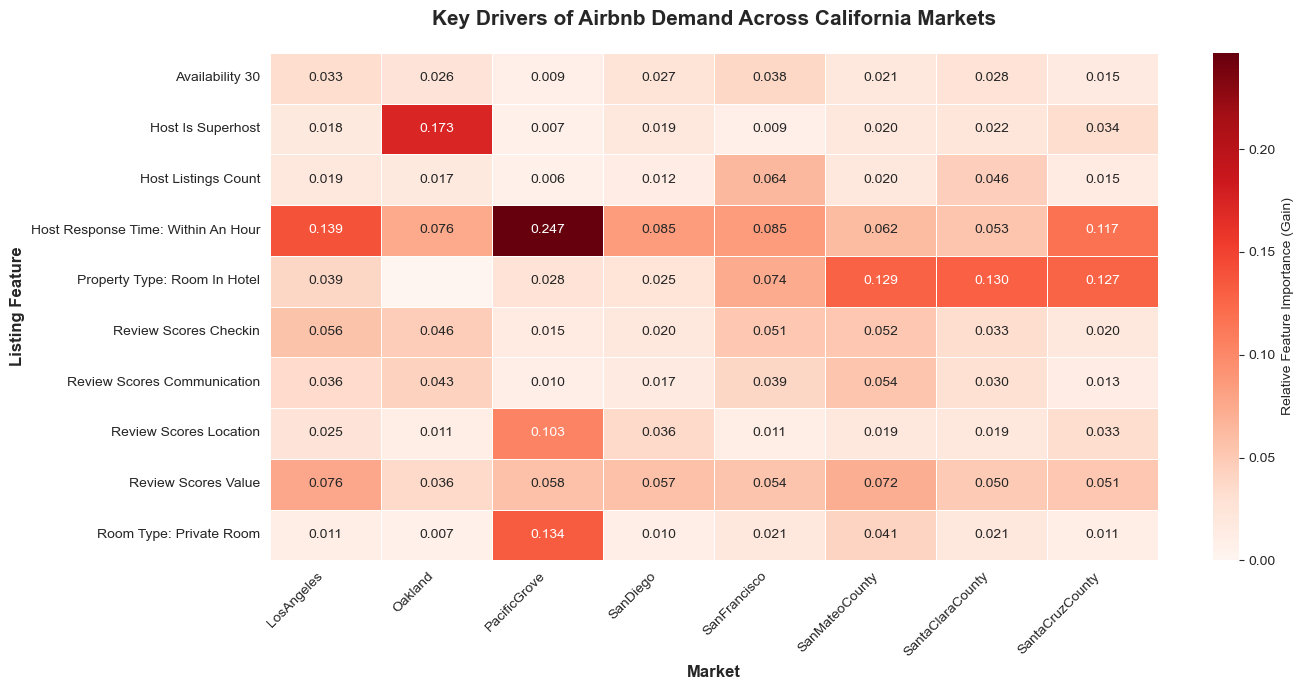

In [50]:
# Heatmap
all_imp = pd.concat(
    [df.assign(Market=market) for market, df in market_drivers.items()],
    ignore_index=True
)

top10_features = (
    all_imp.groupby('Feature')['Importance']
    .mean()
    .nlargest(10)
    .index
)

heatmap_data = all_imp[all_imp['Feature'].isin(top10_features)]
pivot = (
    heatmap_data
    .pivot(index='Feature', columns='Market', values='Importance')
    .fillna(0)
)

pivot.index = [clean_label(f) for f in pivot.index]
annot = pivot.map(lambda x: f"{x:.3f}" if x > 0 else "").values
plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot,
    cmap='Reds',
    annot=annot,
    fmt="",
    linewidths=0.5,
    cbar_kws={'label': 'Relative Feature Importance (Gain)'}
)

plt.title("Key Drivers of Airbnb Demand Across California Markets",
fontsize=15, fontweight='bold', pad=20)
plt.ylabel("Listing Feature", fontsize=12, fontweight='bold')
plt.xlabel("Market", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<a id="sec-6-1-7"></a>
#### 6.1.7 Visualizing The Top 5 Demand Drivers in Santa Clara County

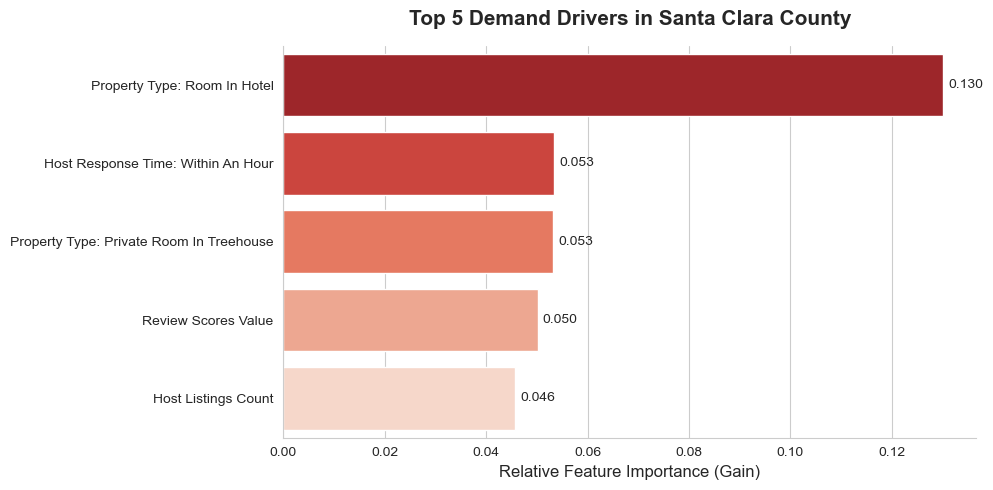

In [51]:
top5_sc = market_drivers['SantaClaraCounty'].head(5).copy()
top5_sc['Clean'] = top5_sc['Feature'].apply(clean_label)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top5_sc,
    x='Importance',
    y='Clean',
    hue='Clean',
    palette='Reds_r',
    legend=False
)
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va='center', fontsize=10
    )

ax.set_title("Top 5 Demand Drivers in Santa Clara County", fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel("Relative Feature Importance (Gain)", fontsize=12)
ax.set_ylabel("")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

<a id="sec-6-1-8"></a>
#### 6.1.8 Visualizing The Top 7 Market Drivers in a Large City (Los Angeles) vs. a Holiday Destination (Pacific Grove)

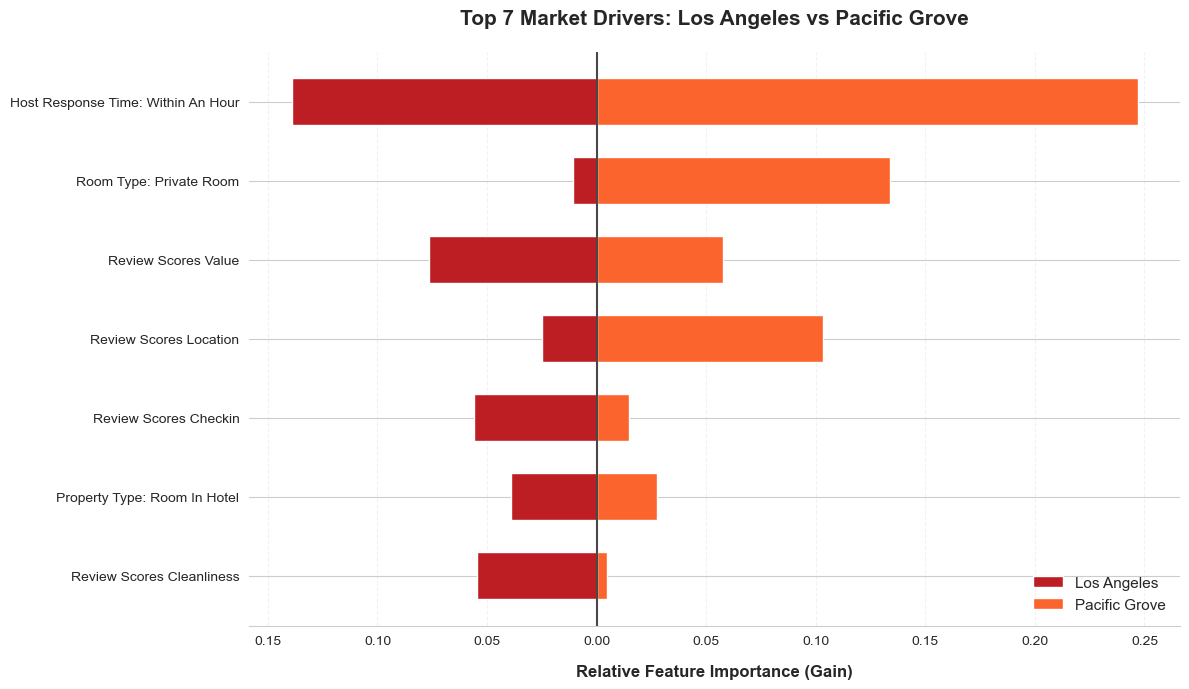

In [52]:
city1, city2 = 'LosAngeles', 'PacificGrove'
color1, color2 = '#BD1E24', '#FC642D'

df1 = market_drivers[city1].set_index('Feature')['Importance']
df2 = market_drivers[city2].set_index('Feature')['Importance']
combined = pd.DataFrame({city1: df1, city2: df2}).fillna(0)
combined['Total'] = combined[city1] + combined[city2]
top7 = combined.sort_values('Total', ascending=True).tail(7)
clean_idx = [clean_label(f) for f in top7.index]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(clean_idx, -top7[city1], color=color1, label='Los Angeles', height=0.6)
ax.barh(clean_idx,  top7[city2], color=color2, label='Pacific Grove', height=0.6)

ax.axvline(0, color='#484848', linewidth=1.5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.2f}"))
ax.set_xlabel("Relative Feature Importance (Gain)", fontsize=12, fontweight='bold', labelpad=12)
ax.set_title("Top 7 Market Drivers: Los Angeles vs Pacific Grove",
fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()


<a id="sec-6-1-9"></a>
#### 6.1.9 Actionable Recommendations : Airbnb Demand Driver Analysis

1. *Treat communication as a core utility, not a customer service task because the first to respond often wins the booking, regardless of location. Implement AI-driven auto-responders to ensure prompt responses.*

2. *The California traveler is currently showing a strong preference for predictability and professional standards. Standardize amenities with high-end linens, branded toiletries and curated guides. Emphasize privacy features with keyless entry and private patios.*


<a id="sec-6-2"></a>
---
### **6.2. Clustering Analysis : Can Airbnb listings be segmented into distinct market groups based on property characteristics, demand, and host behavior?**

Models Used: `K-Means Clustering` | `DBSCAN`

<a id="sec-6-2-1"></a>
#### 6.2.1 Feature Selection

In [53]:
# Select features representing property characteristics, demand and host behavior
cluster_features = [
    "accommodates","bathrooms","bedrooms","beds","price","availability_365",
    "number_of_reviews","reviews_per_month","review_scores_rating","review_scores_cleanliness",
    "review_scores_location","review_scores_value","hosts.time_as_host_years","host_listings_count"
]

# Keep only features that exist
cluster_features = [c for c in cluster_features if c in combined_df.columns]

# Features
X = combined_df[cluster_features].copy()

<a id="sec-6-2-2"></a>
#### 6.2.2 Handling Missing Values (Imputing with KNN, so values are imputed with similar listings)

In [54]:
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)

<a id="sec-6-2-3"></a>
#### 6.2.3 Scaling using **Standard Scaler**

In [55]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

<a id="sec-6-2-4"></a>
#### 6.2.4 Finding Optimal Clusters using **Elbow Method**

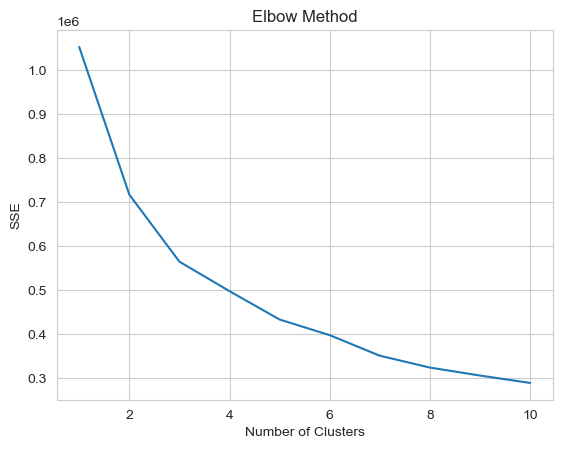

Optimal k: 3


In [56]:
# Elbow method
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='random', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse)
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

# Find elbow
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
print("Optimal k:", kl.elbow)

<a id="sec-6-2-5"></a>
#### 6.2.5 Finding Optimal Clusters using **Silhouette Score**

K=2, Silhouette Score: 0.2878
K=3, Silhouette Score: 0.4030
K=4, Silhouette Score: 0.3475
K=5, Silhouette Score: 0.2607
K=6, Silhouette Score: 0.2828


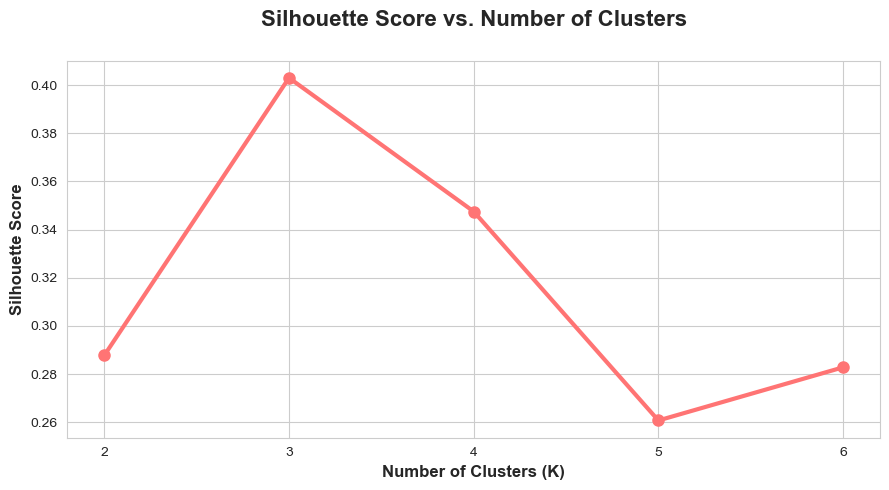

In [57]:
k_values = [2, 3, 4, 5, 6]
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)
    
    # Print the exact number to the screen for your table
    print(f"K={k}, Silhouette Score: {score:.4f}")


#Plot
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='#FF7474', linewidth=3, markersize=8)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=12, fontweight='bold')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

- *When evaluating optimal market segments, our initial Elbow Method curve suggested K=2 clusters. However, with a 2 cluster split, the algorithm is simply dividing the data into two groups of generic listings and offers no actionable insights for travelers or hosts.*

- *To find a more meaningful segmentation, we evaluated the model using the Silhouette Score and it returned with a score of **0.4172 at k=3**, which confirmed that a three cluster structure does have distinct boundaries in the data and is mathematically valid.*

- *The elbow method and silhouette score both indicate that k = 2 provides the strongest statistical fit under the current preprocessing approach. However, k = 3 was ultimately selected because it produces more interpretable and actionable market segments, distinguishing commercial hosts, mainstream listings, and premium listings more clearly.

- *Therefore, we chose to move forward with K=3.*

<a id="sec-6-2-6"></a>
#### 6.2.6 K-Means Clustering

In [58]:
#KMeans using k=3
kmeans_final = KMeans(
    n_clusters=3,
    init='random',
    n_init=20,
    max_iter=300,
    random_state=42
)

clusters = kmeans_final.fit_predict(X_scaled)
combined_df.loc[X.index, "cluster"] = clusters

In [59]:
# Check cluster size
combined_df["cluster"].value_counts()

cluster
0.0    48973
2.0    18389
1.0    13561
Name: count, dtype: int64

In [60]:
# Check cluster characteristics
combined_df.groupby("cluster").mean(numeric_only=True).round(2)

,latitude,longitude,host_listings_count,calculated_host_listings_count,accommodates,bathrooms,bedrooms,beds,price,availability_30,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,has_reviews,cluster2,dbscan_cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,34.91,-119.31,62.38,13.30,2.99,1.19,1.25,1.63,150.84,12.74,...,4.80,4.82,4.78,4.88,4.87,4.81,4.72,1.00,1.00,-0.00
1.0,34.48,-118.89,44.12,15.63,8.64,2.90,3.71,4.90,515.94,15.12,...,4.52,4.53,4.49,4.59,4.58,4.54,4.43,0.94,0.94,-0.02
2.0,34.79,-119.16,438.56,46.61,3.54,1.48,1.63,1.85,227.81,16.51,...,0.03,0.03,0.03,0.04,0.04,0.04,0.02,0.02,0.00,-0.00


In [68]:
combined_df["review_scores_rating"].isna().groupby(combined_df["cluster"]).mean()

cluster
0.0    0.0
1.0    0.0
2.0    0.0
Name: review_scores_rating, dtype: float64

<a id="sec-6-2-7"></a>
#### 6.2.7 Price Distribution of Clusters

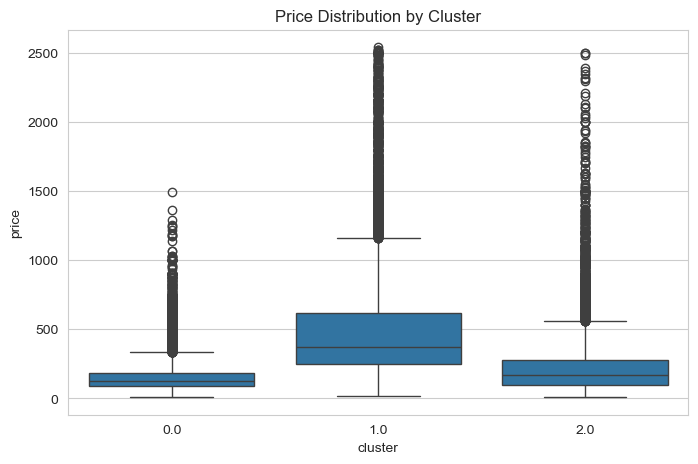

In [61]:
# Plotting price distribution by cluster
plt.figure(figsize=(8,5))
sns.boxplot(data=combined_df, x="cluster", y="price")
plt.title("Price Distribution by Cluster")
plt.show()

<a id="sec-6-2-8"></a>
#### 6.2.8 Running K-Means (PCA Cluster Map)

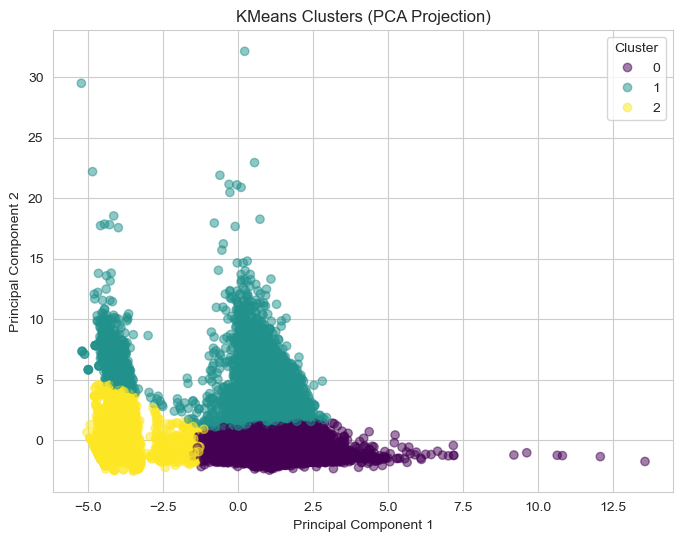

In [73]:
# PCA cluster map
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=combined_df.loc[X.index,"cluster"],
    cmap="viridis",
    alpha=0.5
)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

<a id="sec-6-2-9"></a>
#### 6.2.9 DBSCAN Analysis

DBSCAN clusters: 2
Noise points: 436 (0.5%)
-1      436
 0    80463
 1       24
Name: count, dtype: int64
Silhouette (excluding noise): 0.5973176799040085


,accommodates,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,host_listings_count
dbscan_cluster,,,,,,,,,,,,,
0.0,4.023,1.546,1.747,2.243,230.033,209.601,47.213,1.446,3.672,3.655,3.682,3.608,143.098
1.0,2.042,10.979,0.750,1.208,45.667,345.750,72.208,1.084,4.613,4.388,4.752,4.645,33.208


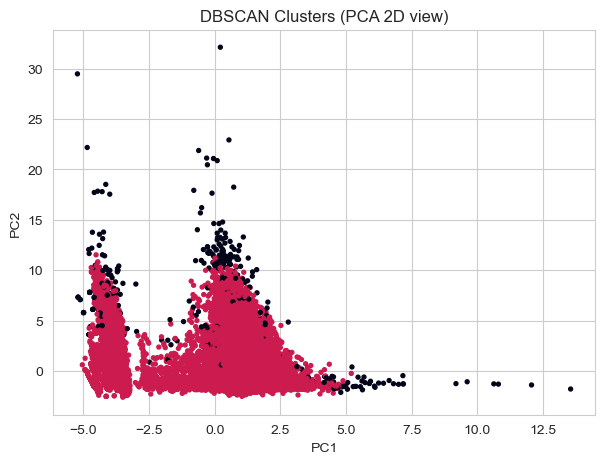

In [70]:
# Feature Selection
cluster_features = [
    "accommodates","bathrooms","bedrooms","beds","price",
    "availability_365","number_of_reviews","reviews_per_month",
    "review_scores_rating","review_scores_cleanliness",
    "review_scores_location","review_scores_value",
    "host_listings_count","host_response_rate","host_acceotance_rate"

]
cluster_features = [c for c in cluster_features if c in combined_df.columns]
X = combined_df[cluster_features].copy()

# Imputing missing values with median
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(X)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Run DBSCAN
eps = 2
min_samples = 10
db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)
combined_df.loc[X.index, "dbscan_cluster"] = labels

# Clustering Results
n_noise = (labels == -1).sum()
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("DBSCAN clusters:", n_clusters)
print("Noise points:", n_noise, f"({n_noise/len(labels):.1%})")
print(pd.Series(labels).value_counts().sort_index())

# Silhouette
mask = labels != -1
if len(set(labels[mask])) >= 2:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette (excluding noise):", sil)

# Cluster profile table (Excluding Noise)
profile = combined_df.loc[X.index].copy()
profile = profile[profile["dbscan_cluster"] != -1]
display(profile.groupby("dbscan_cluster")[cluster_features].mean().round(3))

# DBSCAN PCA 2D Visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=8)
plt.title("DBSCAN Clusters (PCA 2D view)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

#### *DBSCAN is not a good clustering algorithm for this dataset because it is not able to find the optimal number of clusters or cluster the data clearly*

<a id="sec-6-2-10"></a>
#### 6.2.10 Actionable Recommendations : Airbnb Clustering Analysis

**Recommendations for Hosts:**

- *Look into reasons for low ratings such as (Cleanliness, Value, Location and Communication) and address them at the earliest.*
- *Improve quality and guest experience by standardizing cleaning procedures, faster customer service response time and better property maintenance.*

---
### **7. Predictive Question**

#### Can clustering-based market segmentation improve the prediction of Airbnb listing demand across California?

Active listings: 62,042 / 80,923 total

Cluster distribution (Active Listings):
cluster
0    49574
1    12115
2      353
Name: count, dtype: int64


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Global Baseline R² (Tuned XGBoost, active listings): 0.5355

Cluster-Specific Models
Cluster 0 (N=49,574): R² = 0.4946
Cluster 1 (N=12,115): R² = 0.4793
Cluster 2 (N=353): R² = 0.0739


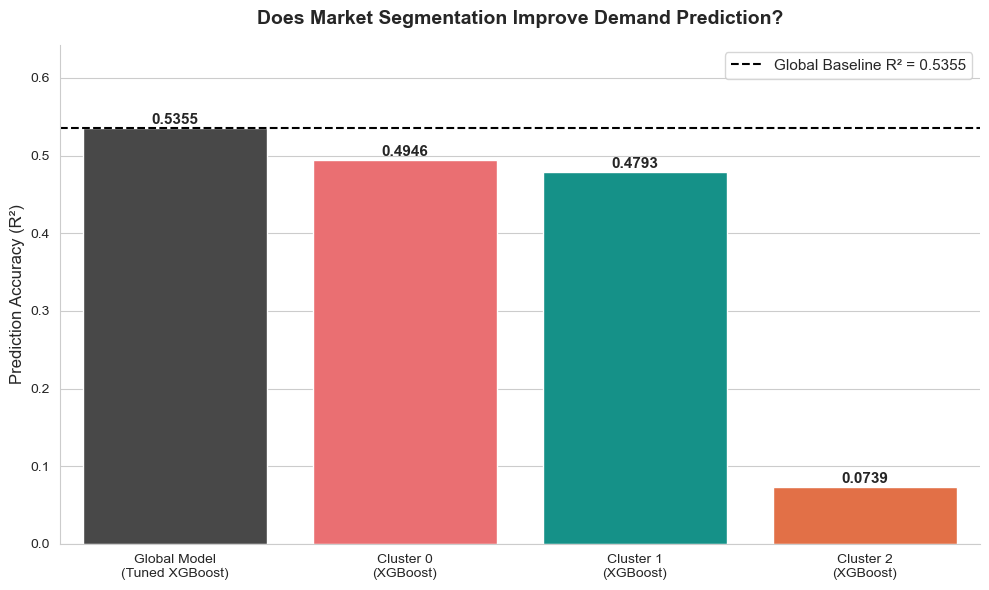

In [69]:
  # Filter to active listings
active_df = ml_df[ml_df[TARGET] > 0].copy()
print(f"Active listings: {len(active_df):,} / {len(ml_df):,} total")

  #Assigning cluster labels
kmeans_cluster_features = [
      "accommodates", "bathrooms", "bedrooms", "beds", "price",
      "availability_365", "number_of_reviews", "reviews_per_month",
      "review_scores_rating", "review_scores_cleanliness",
      "review_scores_location", "review_scores_value", "host_listings_count"
]
kmeans_cluster_features = [c for c in kmeans_cluster_features if c in active_df.columns]

X_active = active_df[kmeans_cluster_features].copy()
X_active_imputed = imputer.transform(X_active)

# Scaling
X_active_scaled = scaler.transform(X_active_imputed)
active_df["cluster"] = kmeans_final.predict(X_active_scaled)

print("\nCluster distribution (Active Listings):")
print(active_df['cluster'].value_counts().sort_index())

# Computing Global Baseline
cols_to_drop = ['location', TARGET, 'cluster', 'number_of_reviews','number_of_reviews_ltm', 'has_reviews']
cols_to_drop = [c for c in cols_to_drop if c in active_df.columns]

X_all = active_df.drop(columns=cols_to_drop)
y_all = active_df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
global_model = xgb.XGBRegressor(**TUNED_PARAMS)
global_model.fit(X_tr, y_tr)
global_r2 = r2_score(y_te, global_model.predict(X_te))
print(f"\nGlobal Baseline R² (Tuned XGBoost, active listings): {global_r2:.4f}")

# Training cluster-specific XGBoost models
cluster_performance = {}
print("\nCluster-Specific Models")

for cluster_id in sorted(active_df['cluster'].dropna().unique()):
    c_df = active_df[active_df['cluster'] == cluster_id]
    if len(c_df) < 100:
        continue
    X_c = c_df.drop(columns=cols_to_drop)
    y_c = c_df[TARGET]
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
    model_c = xgb.XGBRegressor(**TUNED_PARAMS)
    model_c.fit(X_tr_c, y_tr_c)

    r2_c = r2_score(y_te_c, model_c.predict(X_te_c))
    cluster_performance[f"Cluster {int(cluster_id)}"] = r2_c
    print(f"Cluster {int(cluster_id)} (N={len(c_df):,}): R² = {r2_c:.4f}")

# Plotting the Comparison
plot_labels = ['Global Model\n(Tuned XGBoost)'] + [f"{k}\n(XGBoost)" for k in cluster_performance]
scores = [global_r2] + list(cluster_performance.values())
colors = ['#484848', '#FF5A5F', '#00A699', '#FC642D']
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=plot_labels, y=scores, hue=plot_labels, palette=colors[:len(plot_labels)], legend=False)
plt.axhline(global_r2, color='black', linestyle='--', linewidth=1.5, label=f'Global Baseline R² = {global_r2:.4f}')
for i, v in enumerate(scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11, fontweight='bold')
plt.title("Does Market Segmentation Improve Demand Prediction?", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Prediction Accuracy (R²)", fontsize=12)
plt.xlabel("")
plt.ylim(0, max(scores) * 1.2)
plt.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

<a id="sec-8"></a>
### **8. Conclusion**

Clustering could improve market segmentation, but with important nuances. Our analysis shows that applying a 'one-size-fits-all' Global Model captures overall patterns more effectively, while segmentation reveals differences in predictability across distinct market segments. By segmenting the market first using K-Means, we uncovered several key insights:

**Targeted Accuracy Trade-offs**: While segmentation allows us to analyze subgroups more closely, the XGBoost models trained on Cluster 0 (R² = 0.4946) and Cluster 1 (R² = 0.4793) underperformed the Global Baseline (R² = 0.5355). Cluster 2 (R² = 0.0739) significantly underperformed the tuned Global Baseline. This suggests that the global model is better at capturing overall demand patterns, while cluster-specific models may suffer from reduced sample size or weaker signal within segments.

**Cluster-Level Variability**: The most valuable insight from segmentation is the difference in predictability across clusters. While Cluster 0 and Cluster 1 show moderate predictive performance, Cluster 2 is highly unpredictable (R² = 0.0739). This indicates that certain segments of the market—particularly those dominated by commercial hosts or irregular listing behavior—are not well explained by the available features and may depend on external factors not used in this analysis .

Hence, our analysis shows that Airbnb is not a single, unified market. While segmentation provides valuable insights into different market structures, it does not necessarily improve predictive performance over a global model. Hosts seeking the most accurate pricing or demand predictions may benefit from global models, while segmentation remains useful for understanding market dynamics and tailoring strategies to specific segments.